In [155]:
# Load data manipulation package
import numpy as np
import pandas as pd

# Load data visualization package
import matplotlib.pyplot as plt
import seaborn as sns

## 1. Data Preparation

### 1.1 Load Dataset and Define Response Variable

In [93]:
data = pd.read_csv('credit-risk-dataset.csv')

data.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [94]:
response_variable = 'loan_status'

y = data[response_variable]
X = data.drop(response_variable, axis=1)

In [95]:
X

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,0.55,Y,4
...,...,...,...,...,...,...,...,...,...,...,...
32576,57,53000,MORTGAGE,1.0,PERSONAL,C,5800,13.16,0.11,N,30
32577,54,120000,MORTGAGE,4.0,PERSONAL,A,17625,7.49,0.15,N,19
32578,65,76000,RENT,3.0,HOMEIMPROVEMENT,B,35000,10.99,0.46,N,28
32579,56,150000,MORTGAGE,5.0,PERSONAL,B,15000,11.48,0.10,N,26


### 1.2 Split Train-Test Data

In [96]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.3, random_state=42)

In [97]:
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (22806, 11)
X_test shape: (9775, 11)
y_train shape: (22806,)
y_test shape: (9775,)


#### Construct data_train
----

In [98]:
data_train = pd.concat([X_train, y_train], axis=1)
data_train.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,loan_status
11491,26,62000,RENT,1.0,DEBTCONSOLIDATION,B,10000,11.26,0.16,N,2,0
3890,23,39000,MORTGAGE,3.0,EDUCATION,C,5000,12.98,0.13,N,4,0
17344,24,35000,RENT,1.0,DEBTCONSOLIDATION,A,12000,6.54,0.34,N,2,1
13023,24,86000,RENT,1.0,HOMEIMPROVEMENT,B,12000,10.65,0.14,N,3,0
29565,42,38400,RENT,4.0,MEDICAL,B,13000,NaN,0.34,N,11,1


## 2. Data Exploration
---

### 2.1 Exploratory Data Analysis

#### Check for missing values
---

In [99]:
data_train.isnull().sum()

person_age                       0
person_income                    0
person_home_ownership            0
person_emp_length              639
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_int_rate                 2200
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
loan_status                      0
dtype: int64

In [100]:
data_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 22806 entries, 11491 to 10456
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  22806 non-null  int64  
 1   person_income               22806 non-null  int64  
 2   person_home_ownership       22806 non-null  object 
 3   person_emp_length           22167 non-null  float64
 4   loan_intent                 22806 non-null  object 
 5   loan_grade                  22806 non-null  object 
 6   loan_amnt                   22806 non-null  int64  
 7   loan_int_rate               20606 non-null  float64
 8   loan_percent_income         22806 non-null  float64
 9   cb_person_default_on_file   22806 non-null  object 
 10  cb_person_cred_hist_length  22806 non-null  int64  
 11  loan_status                 22806 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 2.3+ MB


#### Predictor 1 : person_age
----

In [101]:
# Descriptive Statistic
data_train['person_age'].describe()

count    22806.000000
mean        27.722880
std          6.336638
min         20.000000
25%         23.000000
50%         26.000000
75%         30.000000
max        144.000000
Name: person_age, dtype: float64

In [102]:
data_train.groupby('loan_status')['person_age'].describe()

,count,mean,std,min,25%,50%,75%,max
loan_status,,,,,,,,
0,17831.0,27.784981,6.337859,20.0,23.0,26.0,30.0,144.0
1,4975.0,27.500302,6.327888,20.0,23.0,26.0,30.0,70.0


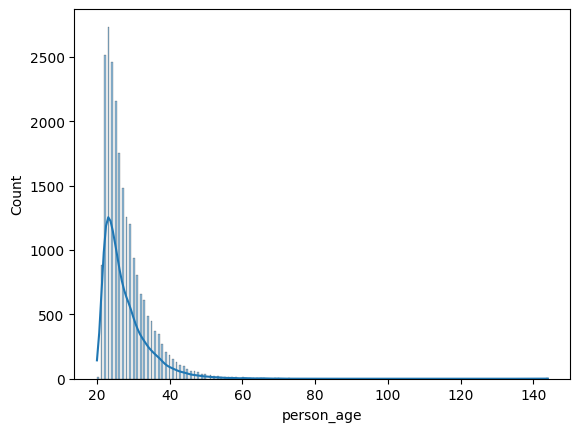

In [103]:
# Distribution Plot of person_age
_ = sns.histplot(data=data_train, x='person_age', kde=True)

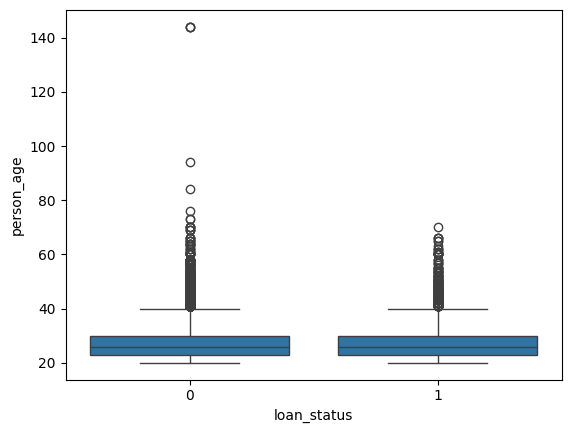

In [104]:
_ = sns.boxplot(data=data_train, x='loan_status', y='person_age')

In [105]:
# Calculate Q1 and Q2
q1_person_age = data_train['person_age'].quantile(0.25)
q3_person_age = data_train['person_age'].quantile(0.75)

iqr_person_age = q3_person_age - q1_person_age

min_person_age = q1_person_age - 1.5 * iqr_person_age
max_person_age = q3_person_age + 1.5 * iqr_person_age

print(min_person_age, max_person_age)

12.5 40.5


In [106]:
adj_min_age = 21
adj_max_age = 55

outliers_person_min_age = data_train['person_age'] < adj_min_age
outliers_person_max_age = data_train['person_age'] > adj_max_age

outliers_person_age = np.where(outliers_person_min_age | outliers_person_max_age)
print(f"number of outliers person age: {len(outliers_person_min_age)}")

number of outliers person age: 22806


In [107]:
data_train['person_age'].isna().sum()

np.int64(0)

##### Summary
1. There's no significant age different between the default and non-default group.
2. The youngest debtor is +-20 years old, and the oldest one is 140++ years old.
3.

#### Predictor 2 : Person Income
---

In [108]:
data_train['person_income'].describe()

count    2.280600e+04
mean     6.620697e+04
std      6.387456e+04
min      4.000000e+03
25%      3.852475e+04
50%      5.500000e+04
75%      7.963500e+04
max      6.000000e+06
Name: person_income, dtype: float64

In [109]:
data_train.groupby('loan_status')['person_income'].describe()

,count,mean,std,min,25%,50%,75%,max
loan_status,,,,,,,,
0,17831.0,70924.834726,68751.340817,7000.0,42000.0,60000.0,84996.0,6000000.0
1,4975.0,49297.585126,37369.816993,4000.0,30000.0,41277.0,59486.0,648000.0


<Axes: xlabel='loan_status', ylabel='person_income'>

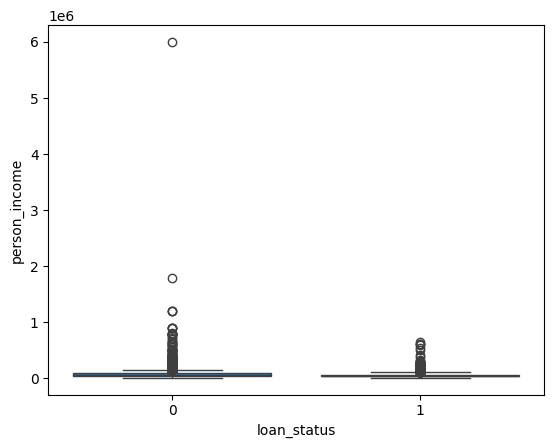

In [110]:
sns.boxplot(data=data_train, x='loan_status', y='person_income')

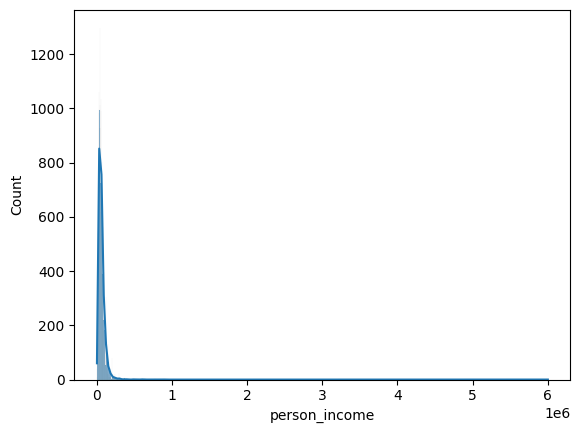

In [111]:
_ = sns.histplot(data=data_train, x='person_income', kde=True)

#### Predictor 3 : person_home_ownership
---

In [114]:
def create_crosstab(data, predictor):
    crosstab = pd.crosstab(
        data[predictor],
        data[response_variable],
    )

    crosstab['odds'] = np.round(crosstab[1] / crosstab[0], 2)
    crosstab = crosstab.sort_values(by='odds', ascending=False)

    return crosstab

create_crosstab(data_train, 'person_home_ownership')

loan_status,0,1,odds
person_home_ownership,,,
OTHER,52,27,0.52
RENT,7860,3638,0.46
MORTGAGE,8227,1180,0.14
OWN,1692,130,0.08


In [113]:
# Checking missing value
data_train['person_home_ownership'].isna().sum()

np.int64(0)

<Axes: xlabel='person_home_ownership', ylabel='count'>

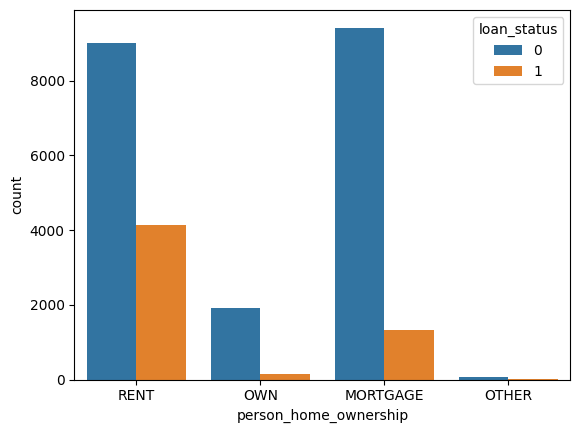

In [80]:
sns.countplot(data=data_train, x='person_home_ownership', hue=response_variable)

## 2. Check Correlation
---

In [116]:
# Define data with numerical predictors
num_columns = ['person_age',
               'person_income',
               'person_emp_length',
               'loan_amnt',
               'loan_int_rate',
               'loan_percent_income',
               'cb_person_cred_hist_length']

# Define data with categorical predictors
cat_columns = ['person_home_ownership',
               'loan_intent',
               'loan_grade',
               'cb_person_default_on_file']

In [117]:
# Calculate Pearson correlation coefficient from numerical predictors
data_train_corr = data_train[num_columns].corr(method = 'pearson')

data_train_corr

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length
person_age,1.000000,0.190499,0.171397,0.054560,0.014319,-0.045562,0.859739
person_income,0.190499,1.000000,0.138115,0.263430,0.001691,-0.248180,0.119455
person_emp_length,0.171397,0.138115,1.000000,0.113166,-0.057092,-0.055841,0.155085
loan_amnt,0.054560,0.263430,0.113166,1.000000,0.140190,0.570820,0.047096
loan_int_rate,0.014319,0.001691,-0.057092,0.140190,1.000000,0.114287,0.018522
loan_percent_income,-0.045562,-0.248180,-0.055841,0.570820,0.114287,1.000000,-0.031308
cb_person_cred_hist_length,0.859739,0.119455,0.155085,0.047096,0.018522,-0.031308,1.000000


<Axes: >

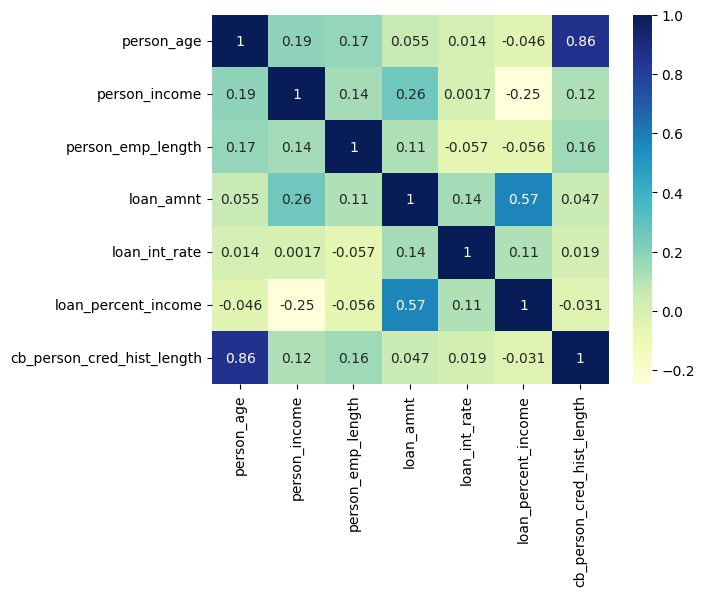

In [119]:
# Plot the heatmap correlation
sns.heatmap(data = data_train_corr,
            cmap = "YlGnBu",
            annot = True)

In [125]:
def create_binning(data, predictor, num_of_bins):
    data[predictor + "_bin"] = pd.qcut(data[predictor], q=num_of_bins)
    return data

In [126]:
for column in num_columns:
    data_train_binned = create_binning(data_train, column, 4)

In [127]:
crosstab_numericals = []

for column in num_columns:
    crosstab = pd.crosstab(
        data_train_binned[column + '_bin'],
        data_train_binned[response_variable],
        margins = True
    )
    crosstab_numericals.append(crosstab)

In [131]:
crosstab_numericals

[loan_status         0     1    All
 person_age_bin                    
 (19.999, 23.0]   4671  1469   6140
 (23.0, 26.0]     5007  1361   6368
 (26.0, 30.0]     3856  1026   4882
 (30.0, 144.0]    4297  1119   5416
 All             17831  4975  22806,
 loan_status               0     1    All
 person_income_bin                       
 (3999.999, 38524.75]   3433  2269   5702
 (38524.75, 55000.0]    4483  1221   5704
 (55000.0, 79635.0]     4731   967   5698
 (79635.0, 6000000.0]   5184   518   5702
 All                   17831  4975  22806,
 loan_status                0     1    All
 person_emp_length_bin                    
 (-0.001, 2.0]           5533  2051   7584
 (2.0, 4.0]              3510   917   4427
 (4.0, 7.0]              4460  1023   5483
 (7.0, 123.0]            3885   788   4673
 All                    17388  4779  22167,
 loan_status             0     1    All
 loan_amnt_bin                         
 (499.999, 5000.0]    5257  1368   6625
 (5000.0, 8000.0]     4243   8

In [129]:
crosstab_categoricals = []

for column in cat_columns:
    crosstab = pd.crosstab(
        data_train_binned[column],
        data_train_binned[response_variable],
        margins = True
    )
    crosstab_categoricals.append(crosstab)

In [130]:
crosstab_categoricals

[loan_status                0     1    All
 person_home_ownership                    
 MORTGAGE                8227  1180   9407
 OTHER                     52    27     79
 OWN                     1692   130   1822
 RENT                    7860  3638  11498
 All                    17831  4975  22806,
 loan_status            0     1    All
 loan_intent                          
 DEBTCONSOLIDATION   2647  1021   3668
 EDUCATION           3734   786   4520
 HOMEIMPROVEMENT     1865   653   2518
 MEDICAL             3096  1141   4237
 PERSONAL            3084   772   3856
 VENTURE             3405   602   4007
 All                17831  4975  22806,
 loan_status      0     1    All
 loan_grade                     
 A             6766   764   7530
 B             6102  1208   7310
 C             3647   928   4575
 D             1022  1474   2496
 E              242   434    676
 F               51   128    179
 G                1    39     40
 All          17831  4975  22806,
 loan_status   

In [132]:
# Put all two in a crosstab_list
crosstab_list = crosstab_numericals + crosstab_categoricals

In [147]:
crosstab_categoricals[0][0]['MORTGAGE']

np.int64(8227)

In [148]:
WOE_list = []

IV_list = []

for crosstab in crosstab_list:
    crosstab['p_good'] = crosstab[0] / crosstab[0]['All']
    crosstab['p_bad'] = crosstab[1] / crosstab[1]['All']
    crosstab['WOE'] = np.log(crosstab['p_good'] / crosstab['p_bad'])
    crosstab['contribution'] = (crosstab['p_good'] - crosstab['p_bad']) * crosstab['WOE']

    IV = crosstab['contribution'][:-1].sum()
    add_IV = {
        'characteristic': crosstab.index.name,
        'Information Value': IV,
    }

    WOE_list.append(crosstab)
    IV_list.append(add_IV)

In [149]:
crosstab_list

[loan_status         0     1    All    p_good     p_bad       WOE  contribution
 person_age_bin                                                                
 (19.999, 23.0]   4671  1469   6140  0.261960  0.295276 -0.119722      0.003989
 (23.0, 26.0]     5007  1361   6368  0.280803  0.273568  0.026104      0.000189
 (26.0, 30.0]     3856  1026   4882  0.216253  0.206231  0.047449      0.000476
 (30.0, 144.0]    4297  1119   5416  0.240985  0.224925  0.068969      0.001108
 All             17831  4975  22806  1.000000  1.000000  0.000000      0.000000,
 loan_status               0     1    All    p_good     p_bad       WOE  \
 person_income_bin                                                        
 (3999.999, 38524.75]   3433  2269   5702  0.192530  0.456080 -0.862418   
 (38524.75, 55000.0]    4483  1221   5704  0.251416  0.245427  0.024109   
 (55000.0, 79635.0]     4731   967   5698  0.265324  0.194372  0.311180   
 (79635.0, 6000000.0]   5184   518   5702  0.290730  0.104121  1

In [152]:
IV_table = pd.DataFrame(IV_list)
IV_table

,characteristic,Information Value
0,person_age_bin,0.005761
1,person_income_bin,0.441132
2,person_emp_length_bin,0.059162
3,loan_amnt_bin,0.076986
4,loan_int_rate_bin,0.561895
5,loan_percent_income_bin,0.606650
6,cb_person_cred_hist_length_bin,0.003737
7,person_home_ownership,0.386431
8,loan_intent,0.088282
9,loan_grade,0.858398


The rule of thumb regarding IV:
- Less than 0.02 : generally unpredictive
- 0.02 to 0.1 : weak
- 0.1 to 0.3 : medium
- 0.3+ : strong

In [154]:
strength = []

for iv in IV_table['Information Value']:
    if iv < 0.02:
        strength.append('Unpredictive')
    elif 0.02 <= iv < 0.1:
        strength.append('Weak')
    elif 0.1 <= iv < 0.3:
        strength.append('Medium')
    else:
        strength.append('Strong')

IV_table = IV_table.assign(strength=strength)
IV_table.sort_values(by='Information Value')

,characteristic,Information Value,strength
6,cb_person_cred_hist_length_bin,0.003737,Unpredictive
0,person_age_bin,0.005761,Unpredictive
2,person_emp_length_bin,0.059162,Weak
3,loan_amnt_bin,0.076986,Weak
8,loan_intent,0.088282,Weak
10,cb_person_default_on_file,0.159914,Medium
7,person_home_ownership,0.386431,Strong
1,person_income_bin,0.441132,Strong
4,loan_int_rate_bin,0.561895,Strong
5,loan_percent_income_bin,0.606650,Strong


In [159]:
# Create a funtion to plot the WOE
def plot_WOE(crosstab):
    """
    Function to plot the WOE trend.

    Parameters
    ----------
    crosstab : DataFrame
    The cross tabulation of the characteristic.

    """
    # Define the plot size
    plt.figure(figsize = (8,4))

    # Plot the WOE
    sns.pointplot(x = crosstab[:-1].T.columns,
                y = 'WOE',
                data = crosstab[:-1],
                markers = 'o',
                linestyles = '--',
                color = 'blue')

    # Rotate the label of x-axis
    plt.xticks(rotation = 20)

In [160]:
# Define the crosstab
crosstab_age = crosstab_list[0]

crosstab_age

loan_status,0,1,All,p_good,p_bad,WOE,contribution
person_age_bin,,,,,,,
"(19.999, 23.0]",4671,1469,6140,0.261960,0.295276,-0.119722,0.003989
"(23.0, 26.0]",5007,1361,6368,0.280803,0.273568,0.026104,0.000189
"(26.0, 30.0]",3856,1026,4882,0.216253,0.206231,0.047449,0.000476
"(30.0, 144.0]",4297,1119,5416,0.240985,0.224925,0.068969,0.001108
All,17831,4975,22806,1.000000,1.000000,0.000000,0.000000


In [172]:
crosstab_age[:-1]['WOE']

person_age_bin
(19.999, 23.0]   -0.119722
(23.0, 26.0]      0.026104
(26.0, 30.0]      0.047449
(30.0, 144.0]     0.068969
Name: WOE, dtype: float64

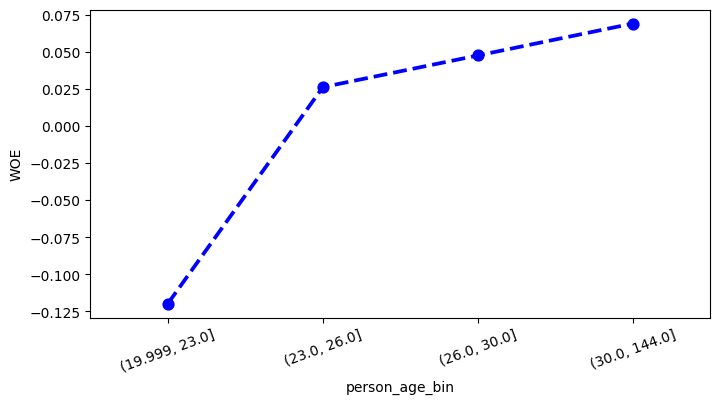

In [161]:
plot_WOE(crosstab_age)